In [1]:
# OFDM Audio Modem – Analysis Notebook
# ========================================
# Imports and Constants

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
import wave
from scipy.signal import correlate, firwin, lfilter
import os



# ── OFDM Constants ─────────────────────────────────────────────────────
N_FFT         = 1024
N_CP          = 1024
N_SYM         = N_FFT + N_CP   # 2048
DATA_CARRIERS = np.arange(1, N_FFT // 2)
N_DATA_SC     = len(DATA_CARRIERS)   # 511

QPSK_NORM          = 1 / np.sqrt(2)
QPSK_CONSTELLATION = np.array([1+1j, -1+1j, -1-1j, 1-1j]) * QPSK_NORM
GRAY_DECODE = {0: (0,0), 1: (0,1), 2: (1,1), 3: (1,0)}

print(f"OFDM Config: N_FFT={N_FFT}, N_CP={N_CP}, N_SYM={N_SYM}, N_DATA_SC={N_DATA_SC}") 

OFDM Config: N_FFT=1024, N_CP=1024, N_SYM=2048, N_DATA_SC=511


In [2]:
# Helper Functions

def load_wav(filename: str):
    """Load WAV file and normalize to [-1, 1]"""
    with wave.open(filename, 'r') as wf:
        fs      = wf.getframerate()
        nframes = wf.getnframes()
        nch     = wf.getnchannels()
        sw      = wf.getsampwidth()
        raw     = wf.readframes(nframes)
    dtype = {1: np.int8, 2: np.int16, 4: np.int32}[sw]
    pcm   = np.frombuffer(raw, dtype=dtype).astype(np.float32)
    if nch == 2:
        pcm = pcm[::2] + pcm[1::2]   # mix to mono
    pcm /= (2.0 ** (8 * sw - 1))  # Normalize to [-1, 1]
    print(f"Loaded {filename}: {nframes} frames @ {fs} Hz ({nframes/fs:.2f} s)")
    return pcm, fs


def mls_sequence(length: int, seed: int = 1) -> np.ndarray:
    """Generate MLS (Maximal Length Sequence)"""
    n_bits = 15
    state  = seed & ((1 << n_bits) - 1) or 1
    out    = []
    for _ in range(length):
        bit   = ((state >> 14) ^ (state >> 13)) & 1
        state = ((state << 1) | bit) & ((1 << n_bits) - 1)
        out.append(1 if bit else -1)
    return np.array(out, dtype=float)


def generate_pilot_sequence(n_carriers: int, pilot_type: str, seed: int) -> np.ndarray:
    """Generate pilot sequence for synchronization"""
    if pilot_type == 'mls':
        real_part = mls_sequence(n_carriers, seed=seed)
        imag_part = mls_sequence(n_carriers, seed=seed + 1)
    else:
        rng       = np.random.default_rng(seed)
        real_part = rng.choice([-1.0, 1.0], size=n_carriers)
        imag_part = rng.choice([-1.0, 1.0], size=n_carriers)
    return (real_part + 1j * imag_part) / np.sqrt(2)


def extract_ofdm_symbol(signal: np.ndarray, offset: int) -> np.ndarray:
    """Extract one OFDM symbol (strip CP, apply FFT)"""
    frame = signal[offset: offset + N_SYM]
    data  = frame[N_CP:]  # strip cyclic prefix
    return np.fft.fft(data) / np.sqrt(N_FFT)


def mle_channel_estimate(X_pilots: np.ndarray, Y_pilots: np.ndarray) -> np.ndarray:
    """MLE channel estimate: H_n = (Σ X_n* · Y_n) / (Σ X_n* · X_n)"""
    numer = np.sum(np.conj(X_pilots) * Y_pilots, axis=0)
    denom = np.sum(np.conj(X_pilots) * X_pilots, axis=0)
    denom = np.where(np.abs(denom) < 1e-12, 1e-12, denom)
    return numer / denom


def generate_reference_chirp(duration_s: float, f0: float, f1: float, fs: int) -> np.ndarray:
    """Generate reference chirp for synchronization"""
    t   = np.arange(int(duration_s * fs)) / fs
    k   = (f1 - f0) / duration_s
    sig = np.sin(2 * np.pi * (f0 * t + 0.5 * k * t**2))
    fade = int(0.02 * fs)
    win  = np.ones_like(sig)
    win[:fade]  = np.linspace(0, 1, fade)
    win[-fade:] = np.linspace(1, 0, fade)
    return sig * win


print("Helper functions loaded")

Helper functions loaded


In [3]:
# STEP 1: Load Audio Files and Compare TX/RX Pilots in Time Domain

# Load MLS audio files
tx_mls_audio, fs_tx = load_wav('/home/arnav/files/tx_noise.wav')
rx_mls_audio, fs_rx = load_wav('/home/arnav/files/rx_noise.wav')

print(f"\nSample rates: TX={fs_tx} Hz, RX={fs_rx} Hz")
print(f"Audio lengths: TX={len(tx_mls_audio)} samples ({len(tx_mls_audio)/fs_tx:.2f}s), RX={len(rx_mls_audio)} samples ({len(rx_mls_audio)/fs_rx:.2f}s)")

# Load metadata
meta_tx = np.load('/home/arnav/files/tx_mls_meta.npz', allow_pickle=True)
pilot_type  = str(meta_tx['pilot_type'][0])
seed        = int(meta_tx['seed'][0])
M           = int(meta_tx['pilot_blocks'][0])
K           = int(meta_tx['pilot_every'][0])
total_data_blks = int(meta_tx['total_data_blks'][0])
pilots_fd_tx = meta_tx['pilots_fd']

print(f"\nMetadata: pilot_type={pilot_type}, seed={seed}, M leading pilots={M}, K pilot every={K} blocks")
print(f"Total data blocks: {total_data_blks}")
print(f"TX Pilot shape (frequency domain): {pilots_fd_tx.shape}")

Loaded /home/arnav/files/tx_noise.wav: 52288 frames @ 48000 Hz (1.09 s)
Loaded /home/arnav/files/rx_noise.wav: 240000 frames @ 48000 Hz (5.00 s)

Sample rates: TX=48000 Hz, RX=48000 Hz
Audio lengths: TX=52288 samples (1.09s), RX=240000 samples (5.00s)

Metadata: pilot_type=mls, seed=42, M leading pilots=4, K pilot every=8 blocks
Total data blocks: 13
TX Pilot shape (frequency domain): (511,)


In [4]:
# Synchronization: Find pilot block timing

def coarse_chirp_sync(signal: np.ndarray, fs: int) -> int:
    """Coarse synchronization via chirp correlation"""
    ref   = generate_reference_chirp(0.3, 100, 8000, fs)
    ds    = 4  # downsample for speed
    sig_d = signal[::ds]
    ref_d = ref[::ds]
    xc    = correlate(sig_d, ref_d, mode='full')
    peak  = np.argmax(np.abs(xc)) - len(ref_d) + 1
    coarse = peak * ds
    print(f"Chirp sync: estimated start sample = {coarse}")
    return max(0, coarse)


def fine_cp_sync(signal: np.ndarray, start: int, search_range: int = 512) -> int:
    """Fine timing via CP correlation"""
    best_score = -np.inf
    best_off   = start
    for delta in range(-search_range, search_range):
        off   = start + delta
        if off + N_SYM > len(signal):
            break
        frame = signal[off: off + N_SYM]
        cp    = frame[:N_CP]
        body  = frame[N_SYM - N_CP:]
        score = np.real(np.dot(cp, np.conj(body)))
        if score > best_score:
            best_score = score
            best_off   = off
    print(f"Fine CP sync: refined start = {best_off} (delta={best_off - start})")
    return best_off


def estimate_cfo(signal: np.ndarray, symbol_offset: int) -> float:
    """Carrier Frequency Offset estimation from CP correlation"""
    frame  = signal[symbol_offset: symbol_offset + N_SYM]
    cp     = frame[:N_CP]
    body   = frame[N_SYM - N_CP:]
    angle  = np.angle(np.dot(body, np.conj(cp)))
    cfo    = angle / (2 * np.pi)
    print(f"CFO estimate: {cfo:.6f} (normalised bins)")
    return cfo


def correct_cfo(signal: np.ndarray, cfo_norm: float, fs: int) -> np.ndarray:
    """Apply CFO correction"""
    n = np.arange(len(signal))
    return (signal * np.exp(-1j * 2 * np.pi * cfo_norm * n / N_FFT)).real


# Perform synchronization on RX signal
chirp_len   = int(0.3 * fs_rx)
guard_len   = 1024
coarse_start = coarse_chirp_sync(rx_mls_audio, fs_rx)
pilot_start_est = coarse_start + chirp_len + guard_len

pilot_start = fine_cp_sync(rx_mls_audio, pilot_start_est, search_range=2056)

# Estimate and correct CFO
cfo = estimate_cfo(rx_mls_audio, pilot_start)
rx_mls_corrected = correct_cfo(rx_mls_audio, cfo, fs_rx) if abs(cfo) > 1e-6 else rx_mls_audio
print(f"CFO correction applied: {abs(cfo) > 1e-6}")

print(f"\n✓ Synchronization complete")
print(f"  Chirp length: {chirp_len} samples ({chirp_len/fs_rx:.3f}s)")
print(f"  Pilot block start: {pilot_start} samples ({pilot_start/fs_rx:.3f}s)")

Chirp sync: estimated start sample = 52944
Fine CP sync: refined start = 69100 (delta=732)
CFO estimate: 0.000000 (normalised bins)
CFO correction applied: False

✓ Synchronization complete
  Chirp length: 14400 samples (0.300s)
  Pilot block start: 69100 samples (1.440s)


Extracted 4 pilot blocks from RX (frequency domain)
Generated time-domain pilots: TX shape (4, 1024), RX shape (4, 1024)


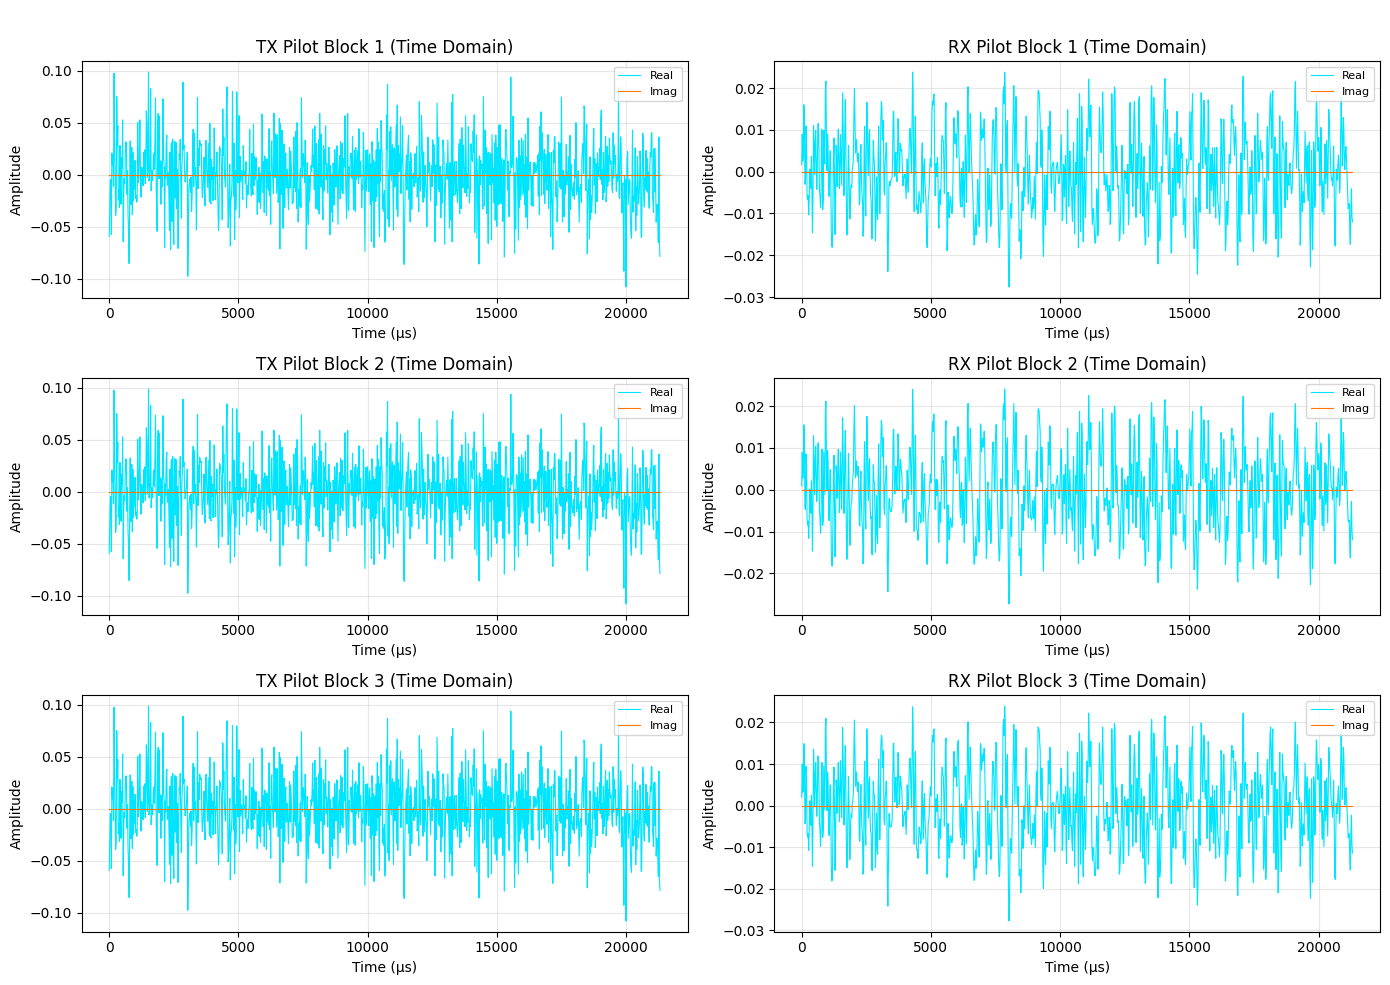

✓ Pilot blocks extracted and visualized


In [5]:
# Extract and Compare Pilot Blocks in Time Domain

# Extract M leading pilot blocks from RX
pilot_rxd_fd = []
cur = pilot_start
for i in range(M):
    fd = extract_ofdm_symbol(rx_mls_corrected, cur)
    pilot_rxd_fd.append(fd[DATA_CARRIERS])
    cur += N_SYM

pilot_rxd_fd = np.array(pilot_rxd_fd)  # (M, N_DATA_SC)
print(f"Extracted {M} pilot blocks from RX (frequency domain)")

# Generate reference TX pilot in frequency domain
pilots_fd_ref = np.tile(pilots_fd_tx, (M, 1))  # (M, N_DATA_SC)

# Convert to time domain for visualization
pilot_tx_time_full = []
pilot_rx_time_full = []

for i in range(M):
    # Build full-bandwidth pilots
    P_tx_full = np.zeros(N_FFT, dtype=complex)
    P_tx_full[DATA_CARRIERS] = pilots_fd_ref[i]
    P_tx_full[N_FFT - DATA_CARRIERS] = np.conj(pilots_fd_ref[i])
    
    P_rx_full = np.zeros(N_FFT, dtype=complex)
    P_rx_full[DATA_CARRIERS] = pilot_rxd_fd[i]
    P_rx_full[N_FFT - DATA_CARRIERS] = np.conj(pilot_rxd_fd[i])
    
    # IFFT to time domain
    pilot_tx_time_full.append(np.fft.ifft(P_tx_full))
    pilot_rx_time_full.append(np.fft.ifft(P_rx_full))

pilot_tx_time_full = np.array(pilot_tx_time_full)
pilot_rx_time_full = np.array(pilot_rx_time_full)

print(f"Generated time-domain pilots: TX shape {pilot_tx_time_full.shape}, RX shape {pilot_rx_time_full.shape}")

# Visualize first 3 pilot blocks comparison
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('TX vs RX Pilot Blocks – Time Domain Comparison', fontsize=14, color='#ffffff')

t_axis = np.arange(N_FFT) / fs_rx * 1e6  # microseconds

for i in range(min(3, M)):
    # TX pilot
    ax = axes[i, 0]
    ax.plot(t_axis, pilot_tx_time_full[i].real, color='#00e5ff', label='Real', lw=0.8)
    ax.plot(t_axis, pilot_tx_time_full[i].imag, color='#ff7700', label='Imag', lw=0.8)
    ax.set_title(f'TX Pilot Block {i+1} (Time Domain)')
    ax.set_xlabel('Time (μs)')
    ax.set_ylabel('Amplitude')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # RX pilot
    ax = axes[i, 1]
    ax.plot(t_axis, pilot_rx_time_full[i].real, color='#00e5ff', label='Real', lw=0.8)
    ax.plot(t_axis, pilot_rx_time_full[i].imag, color='#ff7700', label='Imag', lw=0.8)
    ax.set_title(f'RX Pilot Block {i+1} (Time Domain)')
    ax.set_xlabel('Time (μs)')
    ax.set_ylabel('Amplitude')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✓ Pilot blocks extracted and visualized")


── MLE Channel Estimation ──────────────────────────
Mean |H|:     0.0792
Std  |H|:     0.0908
Min  |H|:     0.0007
Max  |H|:     0.5419


'\n# 3. Channel frequency response magnitude\nax = axes[1]\nax.plot(f_pos / 1e3, 20 * np.log10(np.abs(H_mle) + 1e-12))\nax.set_xlabel(\'Frequency (kHz)\')\nax.set_ylabel(\'|H(f)| (dB)\')\nax.set_title(\'Channel Frequency Response\')\nax.grid(True, alpha=0.3)\n\n# 4. Channel phase response\nax = axes[2]\nax.plot(f_pos / 1e3, H_phase)\nax.set_xlabel(\'Frequency (kHz)\')\nax.set_ylabel(\'Phase (°)\')\nax.set_title(\'Channel Phase Response\')\nax.grid(True, alpha=0.3)\n\nplt.tight_layout()\nplt.show()\n\nprint(f"✓ Channel estimation complete")'

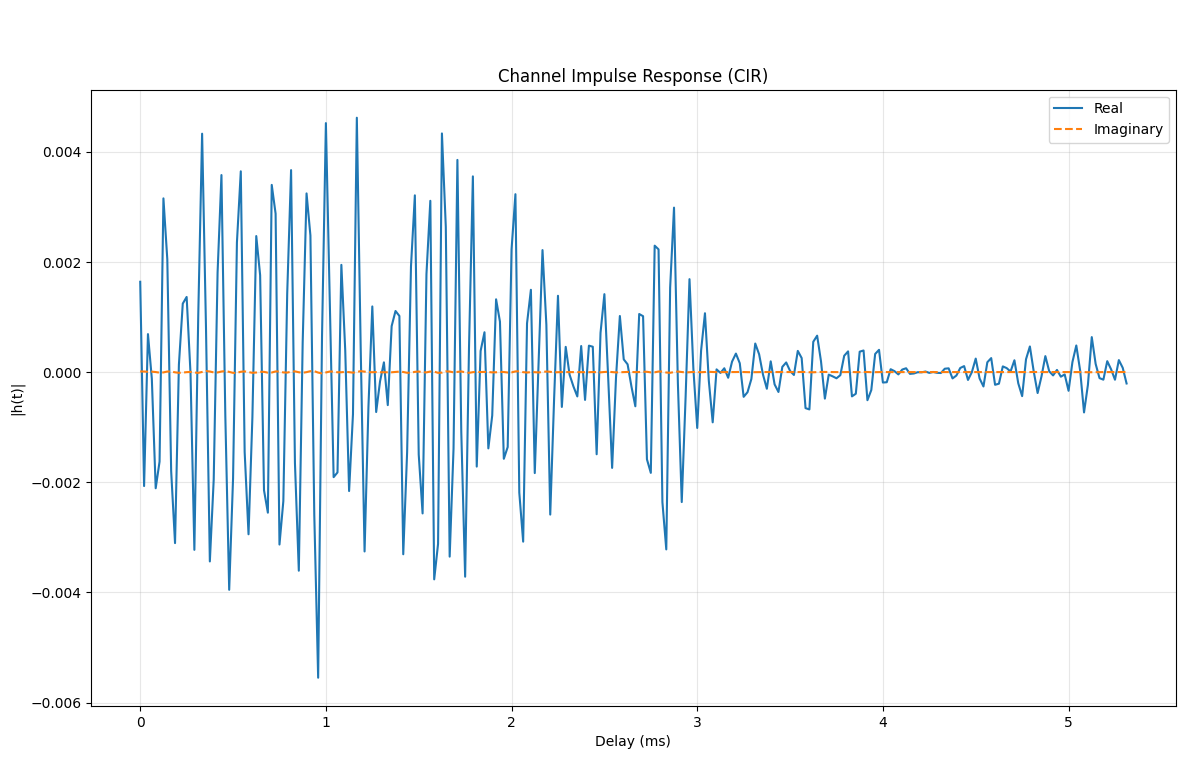

In [6]:
# STEP 2: MLE Channel Estimation from Pilot Blocks

# MLE channel estimation
H_mle = mle_channel_estimate(pilots_fd_ref, pilot_rxd_fd)
H_mle = np.convolve(H_mle, np.ones(5)/5, mode='same')
print("\n── MLE Channel Estimation ──────────────────────────")
print(f"Mean |H|:     {np.mean(np.abs(H_mle)):.4f}")
print(f"Std  |H|:     {np.std(np.abs(H_mle)):.4f}")
print(f"Min  |H|:     {np.min(np.abs(H_mle)):.4f}")
print(f"Max  |H|:     {np.max(np.abs(H_mle)):.4f}")

H_mag_dB = 20 * np.log10(np.abs(H_mle) + 1e-12)
H_phase  = np.angle(H_mle, deg=True)

# Build full-bandwidth H for IFFT
H_full = np.zeros(N_FFT, dtype=complex)

H_full[DATA_CARRIERS] = H_mle
H_full[N_FFT - DATA_CARRIERS] = np.conj(H_mle)
window = np.hanning(N_FFT)
H_full *= window

# Time-domain CIR (Channel Impulse Response)
h_time = np.fft.ifft(H_full)
h_abs = np.abs(h_time)

# Get frequency axis for positive frequencies only
freq_axis = np.fft.fftfreq(N_FFT, 1/fs_rx)
f_pos = freq_axis[DATA_CARRIERS]

# Visualization
fig, axes = plt.subplots(1, figsize=(14, 8))
fig.suptitle('Channel Estimate (MLE)', fontsize=14, color='#ffffff')

t_axis_cir = np.arange(N_FFT) / fs_rx * 1e3  # ms

# 1. CIR magnitude
ax = axes
ax.plot(t_axis_cir[:N_FFT//4], h_time[:N_FFT//4].real, linestyle='-', label='Real')
ax.plot(t_axis_cir[:N_FFT//4], h_time[:N_FFT//4].imag, linestyle='--', label='Imaginary')
ax.set_xlabel('Delay (ms)')
ax.set_ylabel('|h(t)|')
ax.set_title('Channel Impulse Response (CIR)')
ax.grid(True, alpha=0.3)
ax.legend()

"""
# 3. Channel frequency response magnitude
ax = axes[1]
ax.plot(f_pos / 1e3, 20 * np.log10(np.abs(H_mle) + 1e-12))
ax.set_xlabel('Frequency (kHz)')
ax.set_ylabel('|H(f)| (dB)')
ax.set_title('Channel Frequency Response')
ax.grid(True, alpha=0.3)

# 4. Channel phase response
ax = axes[2]
ax.plot(f_pos / 1e3, H_phase)
ax.set_xlabel('Frequency (kHz)')
ax.set_ylabel('Phase (°)')
ax.set_title('Channel Phase Response')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✓ Channel estimation complete")"""

In [7]:
# STEP 3: Extract Data Blocks, Equalization & QPSK Decoding

print("\n── Data Block Extraction ─────────────────────────────")

H_track = H_mle.copy()  # Initialize with initial estimate
data_syms_raw = []
blk_idx = 0
cur = pilot_start + M * N_SYM  # Start after leading pilots

# Extract data blocks with pilot updates every K blocks
while blk_idx < total_data_blks and (cur + N_SYM) <= len(rx_mls_corrected):
    # Insert pilot update every K blocks
    if blk_idx > 0 and blk_idx % K == 0:
        fd_p = extract_ofdm_symbol(rx_mls_corrected, cur)
        p_rx = fd_p[DATA_CARRIERS]
        H_track = p_rx / pilots_fd_tx  # Update channel estimate
        print(f"  Pilot update at block {blk_idx}: mean|H|={np.mean(np.abs(H_track)):.4f}")
        cur += N_SYM
    
    if cur + N_SYM > len(rx_mls_corrected):
        break
    
    # Extract data block
    fd = extract_ofdm_symbol(rx_mls_corrected, cur)
    d_rx = fd[DATA_CARRIERS]
    
    # One-tap equalization
    d_eq = d_rx / H_track
    
    data_syms_raw.append(d_eq)
    blk_idx += 1
    cur += N_SYM

data_syms_raw = np.array(data_syms_raw)
actual_blks = len(data_syms_raw)

print(f"Extracted {actual_blks} data blocks (expected {total_data_blks})")
print(f"Shape: {data_syms_raw.shape} → flattened: {data_syms_raw.reshape(-1).shape}")

# Flatten all equalized symbols
all_syms_eq = data_syms_raw.reshape(-1)

# QPSK Hard Decision
dists = np.abs(all_syms_eq[:, np.newaxis] - QPSK_CONSTELLATION[np.newaxis, :])
qpsk_idx = np.argmin(dists, axis=1)
decided_syms = QPSK_CONSTELLATION[qpsk_idx]

print(f"\n── QPSK Decoding ────────────────────────────────────")
print(f"Total QPSK symbols: {len(all_syms_eq)}")
print(f"EVM RMS: {np.sqrt(np.mean(np.abs(all_syms_eq - decided_syms)**2)) / QPSK_NORM * 100:.2f}%")

# Gray decode to bits
bits = []
for idx in qpsk_idx:
    bits.extend(GRAY_DECODE[idx])
bits = np.array(bits, dtype=np.uint8)

print(f"Decoded bits: {len(bits)} bits ({len(bits)//8} bytes)")

print(f"✓ Data extraction and decoding complete")


── Data Block Extraction ─────────────────────────────
  Pilot update at block 8: mean|H|=0.1699
Extracted 13 data blocks (expected 13)
Shape: (13, 511) → flattened: (6643,)

── QPSK Decoding ────────────────────────────────────
Total QPSK symbols: 6643
EVM RMS: 516.48%
Decoded bits: 13286 bits (1660 bytes)
✓ Data extraction and decoding complete


In [8]:
# STEP 4: Text Reconstruction & Target Reconstruction

print("\n── Target Reconstruction ─────────────────────────────")

# Bits → Bytes
n_bytes = len(bits) // 8
byte_arr = np.packbits(bits[:n_bytes * 8])

# Extract length header (first 4 bytes)
if len(byte_arr) >= 4:
    payload_len = int.from_bytes(byte_arr[:4], 'big')
    text_bytes = byte_arr[4: 4 + payload_len]
else:
    payload_len = 0
    text_bytes = byte_arr

print(f"Payload length (header): {payload_len} bytes")
print(f"Text bytes extracted: {len(text_bytes)} bytes")

# Decode to text
try:
    reconstructed_text = text_bytes.tobytes().decode('utf-8', errors='replace')
    print(f"\n── Reconstructed Text ─────────────────────────────")
    print(f"Length: {len(reconstructed_text)} characters")
    print(f"\nPreview (first 500 chars):")
    print("─" * 70)
    print(reconstructed_text[:500])
    print("─" * 70)
    if len(reconstructed_text) > 500:
        print(f"\n... ({len(reconstructed_text) - 500} more characters)")
except Exception as e:
    print(f"Text reconstruction error: {e}")
    reconstructed_text = ''

print(f"\n✓ Text reconstruction complete")


── Target Reconstruction ─────────────────────────────
Payload length (header): 3249481203 bytes
Text bytes extracted: 1656 bytes

── Reconstructed Text ─────────────────────────────
Length: 1567 characters

Preview (first 500 chars):
──────────────────────────────────────────────────────────────────────
/wgD
Ie�J�4�� éum�Y���6�PT��n��F�6�*�^��z�x�ט��t˛ �]�l�i���荚���8Hui��3�t8+N�>9��\O7�,'�lӑ�@K�G�da[YXK�F��˼�mIT'���xǗG{̦���r���5+��cJ;"�����`��%��Gz�!�$3$Û4�w~-���[*�T�*�*�� �&og`T���m|Bp�}���-�A2�2�󪹟�/��2w�$}�?��������s�.nY��� �W��;���+��ƝS���S�}�P9V3�qm� mVf8y,n��\l�e�GV���r�Rt n�&8�Һ��]�M����6�U[�����S<s�(ܦ(�8��x��U������*�0L?����(k���n���,�b/	(k�
──────────────────────────────────────────────────────────────────────

... (1067 more characters)

✓ Text reconstruction complete



── Constellation Analysis ──────────────────────────


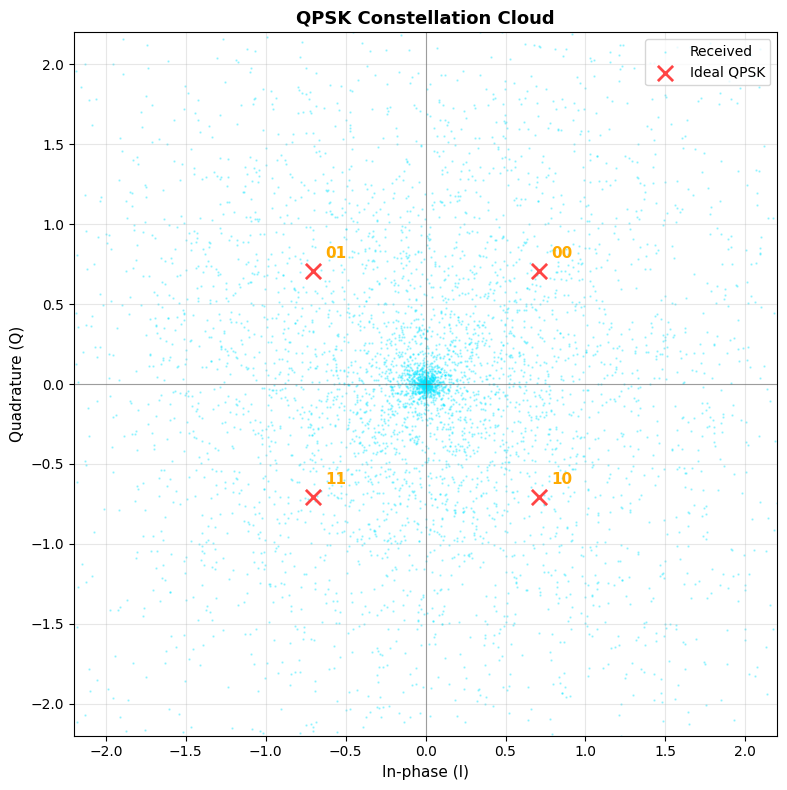

✓ Constellation plotted

── Signal Quality Metrics ───────────────────────────
Mean SNR:    29.59 dB
Median SNR:  17.66 dB
Min SNR:     -2.44 dB
Max SNR:     43.94 dB

EVM (RMS):   516.48%
Symbol Error Rate: 0.9216 (6122/6643 symbols)
Estimated BER:    0.4608
MER:              -11.25 dB

✓ Quality metrics calculated


In [9]:
# STEP 5: Constellation & Quality Metrics

print("\n── Constellation Analysis ──────────────────────────")

# Constellation cloud visualization
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(all_syms_eq.real, all_syms_eq.imag,
           s=0.5, alpha=0.3, color='#00e5ff', rasterized=True, label='Received')

# Ideal QPSK points
ref = QPSK_CONSTELLATION
ax.scatter(ref.real, ref.imag, s=120, marker='x', color='#ff4444',
           linewidths=2, zorder=5, label='Ideal QPSK')

# Label constellation points
labels = ['00', '01', '11', '10']
for i, (r, lbl) in enumerate(zip(ref, labels)):
    ax.annotate(lbl, (r.real + 0.08, r.imag + 0.08),
                color='#ffaa00', fontsize=11, fontweight='bold')

ax.axhline(0, color='#555', lw=0.8, alpha=0.5)
ax.axvline(0, color='#555', lw=0.8, alpha=0.5)
ax.set_aspect('equal')
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-2.2, 2.2)
ax.set_xlabel('In-phase (I)', fontsize=11)
ax.set_ylabel('Quadrature (Q)', fontsize=11)
ax.set_title('QPSK Constellation Cloud', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✓ Constellation plotted")

# Quality Metrics Calculation
print("\n── Signal Quality Metrics ───────────────────────────")

# SNR per sub-carrier (from pilot blocks)
Y_noise = pilot_rxd_fd - pilots_fd_ref * H_mle[np.newaxis, :]
noise_var = np.mean(np.abs(Y_noise)**2, axis=0)
signal_var = np.mean(np.abs(pilots_fd_ref)**2, axis=0)
snr_per_sc = np.where(noise_var > 1e-15, signal_var / noise_var, 0)
snr_db_per_sc = 10 * np.log10(snr_per_sc + 1e-12)

mean_snr_db = 10 * np.log10(np.mean(snr_per_sc) + 1e-12)
median_snr_db = 10 * np.log10(np.median(snr_per_sc) + 1e-12)

print(f"Mean SNR:    {mean_snr_db:.2f} dB")
print(f"Median SNR:  {median_snr_db:.2f} dB")
print(f"Min SNR:     {10 * np.log10(np.min(snr_per_sc) + 1e-12):.2f} dB")
print(f"Max SNR:     {10 * np.log10(np.max(snr_per_sc) + 1e-12):.2f} dB")

# EVM (Error Vector Magnitude)
evm_rms = np.sqrt(np.mean(np.abs(all_syms_eq - decided_syms)**2)) / QPSK_NORM
evm_pct = evm_rms * 100
print(f"\nEVM (RMS):   {evm_pct:.2f}%")

# SER and BER
sym_errors = np.sum(np.abs(all_syms_eq - decided_syms) > QPSK_NORM * 0.5)
ser = sym_errors / len(all_syms_eq)
ber_est = ser / 2
print(f"Symbol Error Rate: {ser:.4f} ({sym_errors}/{len(all_syms_eq)} symbols)")
print(f"Estimated BER:    {ber_est:.4f}")

# MER (Modulation Error Ratio)
signal_power = np.mean(np.abs(decided_syms)**2)
error_power = np.mean(np.abs(all_syms_eq - decided_syms)**2)
mer_db = 10 * np.log10(signal_power / (error_power + 1e-15))
print(f"MER:              {mer_db:.2f} dB")

print(f"\n✓ Quality metrics calculated")

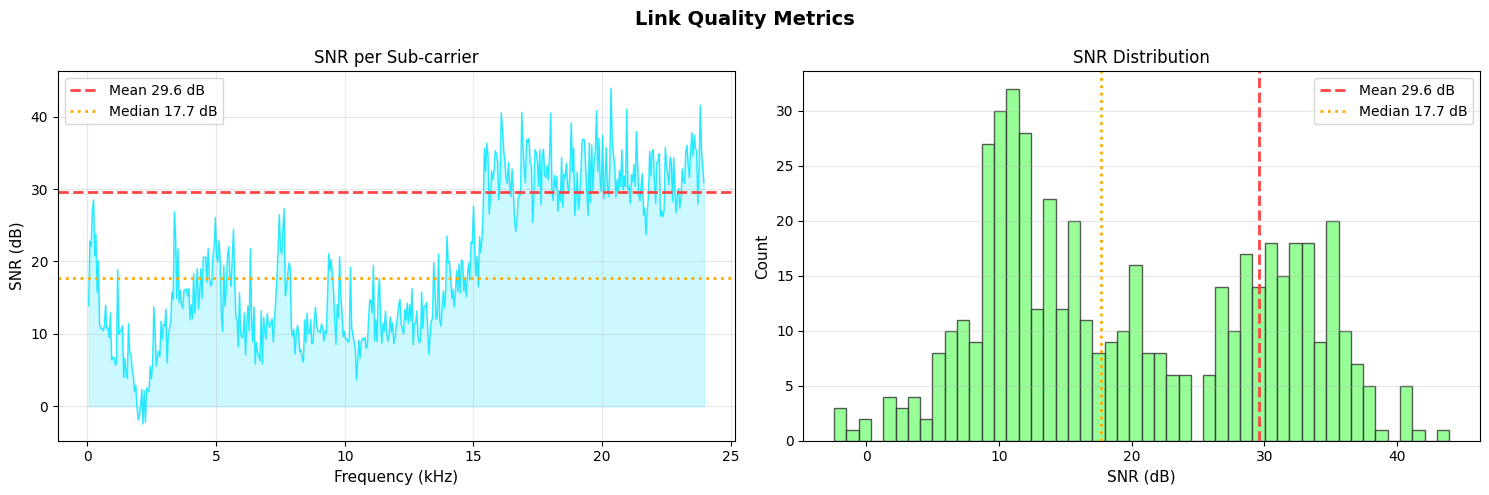

✓ SNR visualization complete


In [10]:
# STEP 6: Detailed SNR and Link Quality Visualization

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Link Quality Metrics', fontsize=14, fontweight='bold')

# 1. SNR per sub-carrier
ax = axes[0]
ax.plot(f_pos / 1e3, snr_db_per_sc, color='#00e5ff', lw=1, alpha=0.8)
ax.axhline(mean_snr_db, color='#ff4444', ls='--', lw=2, label=f'Mean {mean_snr_db:.1f} dB')
ax.axhline(median_snr_db, color='#ffaa00', ls=':', lw=2, label=f'Median {median_snr_db:.1f} dB')
ax.fill_between(f_pos / 1e3, snr_db_per_sc, alpha=0.2, color='#00e5ff')
ax.set_xlabel('Frequency (kHz)', fontsize=11)
ax.set_ylabel('SNR (dB)', fontsize=11)
ax.set_title('SNR per Sub-carrier')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# 2. SNR histogram
ax = axes[1]
counts, bins, patches = ax.hist(snr_db_per_sc, bins=50, color='#7fff7f', 
                                 edgecolor='#333333', alpha=0.8)
ax.axvline(mean_snr_db, color='#ff4444', ls='--', lw=2, label=f'Mean {mean_snr_db:.1f} dB')
ax.axvline(median_snr_db, color='#ffaa00', ls=':', lw=2, label=f'Median {median_snr_db:.1f} dB')
ax.set_xlabel('SNR (dB)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('SNR Distribution')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"✓ SNR visualization complete")

In [11]:
# STEP 7: Summary Report

print("\n" + "=" * 70)
print("AUDIO MODEM – ANALYSIS SUMMARY REPORT")
print("=" * 70)

report_lines = [
    "",
    "TRANSMISSION PARAMETERS",
    "─" * 70,
    f"Sample rate:               {fs_rx} Hz",
    f"CFO (carrier freq offset): {cfo:.6f} normalised bins",
    f"Pilot type:                {pilot_type}",
    f"Leading pilot blocks:      {M}",
    f"Pilot update interval:     Every {K} data blocks",
    f"Total data blocks:         {total_data_blks}",
    f"Actual blocks decoded:     {actual_blks}",
    "",
    
    "FRAME TIMING & SYNCHRONIZATION",
    "─" * 70,
    f"Chirp length:              {chirp_len} samples ({chirp_len/fs_rx:.3f}s)",
    f"Guard period:              {guard_len} samples",
    f"Coarse sync (chirp):       {coarse_start} samples",
    f"Fine sync (pilot start):   {pilot_start} samples ({pilot_start/fs_rx:.3f}s)",
    f"Pilot block size:          {N_SYM} samples (FFT={N_FFT}, CP={N_CP})",
    "",
    
    "CHANNEL ESTIMATION (MLE)",
    "─" * 70,
    f"Mean magnitude |H|:        {np.mean(np.abs(H_mle)):.4f}",
    f"Std deviation |H|:         {np.std(np.abs(H_mle)):.4f}",
    f"Min |H|:                   {np.min(np.abs(H_mle)):.6f}",
    f"Max |H|:                   {np.max(np.abs(H_mle)):.6f}",
    f"Mean phase:                {np.mean(H_phase):.2f}°",
    "",
    
    "DATA RECOVERY & DECODING",
    "─" * 70,
    f"QPSK symbols decoded:      {len(all_syms_eq)}",
    f"Data blocks:               {actual_blks} blocks × {N_DATA_SC} subcarriers",
    f"Bits recovered:            {len(bits)} bits ({len(bits)//8} bytes)",
    f"Payload length (header):   {payload_len} bytes",
    f"Text bytes extracted:      {len(text_bytes)} bytes",
    "",
    
    "SIGNAL QUALITY METRICS",
    "─" * 70,
    f"SNR (mean):                {mean_snr_db:.2f} dB",
    f"SNR (median):              {median_snr_db:.2f} dB",
    f"SNR (min/max):             {10 * np.log10(np.min(snr_per_sc) + 1e-12):.2f} / {10 * np.log10(np.max(snr_per_sc) + 1e-12):.2f} dB",
    f"EVM (RMS):                 {evm_pct:.2f}%",
    f"MER:                       {mer_db:.2f} dB",
    f"Symbol Error Rate (SER):   {ser:.4f} ({sym_errors} errors)",
    f"Estimated BER:             {ber_est:.4f}",
    "",
    
    "TEXT RECONSTRUCTION",
    "─" * 70,
    f"Reconstructed length:      {len(reconstructed_text)} characters",
    f"Preview available:         {'Yes' if len(reconstructed_text) > 0 else 'No'}",
    "",
]

report_text = "\n".join(report_lines)
print(report_text)
print("=" * 70)

# Create and display summary metrics as a nice table
summary_data = {
    'Metric': [
        'Sample Rate',
        'CFO',
        'Leading Pilots',
        'Data Blocks',
        'QPSK Symbols',
        'Bits',
        '─ Mean |H|',
        '─ SNR (mean)',
        '─ EVM',
        '─ MER',
        '─ BER (est)',
        'Text (bytes)'
    ],
    'Value': [
        f'{fs_rx} Hz',
        f'{cfo:.6f}',
        f'{M}',
        f'{actual_blks}/{total_data_blks}',
        f'{len(all_syms_eq)}',
        f'{len(bits)}',
        f'{np.mean(np.abs(H_mle)):.4f}',
        f'{mean_snr_db:.2f} dB',
        f'{evm_pct:.2f}%',
        f'{mer_db:.2f} dB',
        f'{ber_est:.4f}',
        f'{len(text_bytes)}'
    ]
}

import pandas as pd
df = pd.DataFrame(summary_data)
print("\nKEY METRICS SUMMARY:")
print(df.to_string(index=False))

print(f"\n✓ Analysis report complete")
print("=" * 70)


AUDIO MODEM – ANALYSIS SUMMARY REPORT

TRANSMISSION PARAMETERS
──────────────────────────────────────────────────────────────────────
Sample rate:               48000 Hz
CFO (carrier freq offset): 0.000000 normalised bins
Pilot type:                mls
Leading pilot blocks:      4
Pilot update interval:     Every 8 data blocks
Total data blocks:         13
Actual blocks decoded:     13

FRAME TIMING & SYNCHRONIZATION
──────────────────────────────────────────────────────────────────────
Chirp length:              14400 samples (0.300s)
Guard period:              1024 samples
Coarse sync (chirp):       52944 samples
Fine sync (pilot start):   69100 samples (1.440s)
Pilot block size:          2048 samples (FFT=1024, CP=1024)

CHANNEL ESTIMATION (MLE)
──────────────────────────────────────────────────────────────────────
Mean magnitude |H|:        0.0792
Std deviation |H|:         0.0908
Min |H|:                   0.000670
Max |H|:                   0.541901
Mean phase:                6.

ModuleNotFoundError: No module named 'pandas'